In [37]:
import numpy as np
import pandas as pd


In [38]:
df = pd.read_csv("https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv")

# from sklearn.datasets import load_diabetes

In [39]:
df.sample(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
372,9012795,M,21.37,15.10,141.30,1386.0,0.1001,0.15150,0.19320,0.12550,...,21.84,152.10,1535.0,0.1192,0.28400,0.40240,0.19660,0.2730,0.08666,NaN
123,865432,B,14.50,10.89,94.28,640.7,0.1101,0.10990,0.08842,0.05778,...,15.98,102.80,745.5,0.1313,0.17880,0.25600,0.12210,0.2889,0.08006,NaN
250,884948,M,20.94,23.56,138.90,1364.0,0.1007,0.16060,0.27120,0.13100,...,27.00,165.30,2010.0,0.1211,0.31720,0.69910,0.21050,0.3126,0.07849,NaN
60,858970,B,10.17,14.88,64.55,311.9,0.1134,0.08061,0.01084,0.01290,...,17.45,69.86,368.6,0.1275,0.09866,0.02168,0.02579,0.3557,0.08020,NaN


- My target column is: Diagnosis.
- Unwanted columns are: id and Unnamed32

In [40]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [41]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

- So we can see only my target column is Object, means catagories B & M, rest of the aLL columns are float.

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['diagnosis']), df['diagnosis'], test_size=0.2, random_state=13)

- Here I am use noremalization of data, means to zero shifting data. We know in PCA then work well.

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [45]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)

- But once we useing PCA that time:
  - A. Calculate **COVARIENCE Matrics**.
  - B. **Eigan Value** Calculate.
  - C. MAke a new transform data.

In [47]:
X_train_normal = pca.fit_transform(X_train)  # Conarience Matrics -> Eigen Values -> Make new Transform Data.
X_test_normal = pca.transform(X_test)

- **Eigan Values**

In [48]:
pca.explained_variance_

array([1.32991056e+01, 5.72840943e+00, 2.84513643e+00, 1.95363172e+00,
       1.60447867e+00, 1.22814914e+00, 6.57834565e-01, 5.04337138e-01,
       4.33408950e-01, 3.39983603e-01, 3.08853634e-01, 2.67290757e-01,
       2.44630424e-01, 1.59526349e-01, 9.17568150e-02, 7.75175301e-02,
       6.10121595e-02, 5.23853899e-02, 4.94813967e-02, 3.22607690e-02,
       2.97623346e-02, 2.49282046e-02, 2.37093661e-02, 1.78285051e-02,
       1.32981813e-02, 8.21009557e-03, 6.65773079e-03, 1.58219653e-03,
       7.79368123e-04, 1.32795584e-04])

- **Eigen Vectors**

In [49]:
# pca.components_
pca.components_.shape

(30, 30)

- **Veriance in Percentage**

In [50]:
(pca.explained_variance_ratio_)

array([4.42329228e-01, 1.90527317e-01, 9.46294462e-02, 6.49779340e-02,
       5.33650780e-02, 4.08483304e-02, 2.18796258e-02, 1.67742902e-02,
       1.44152134e-02, 1.13078795e-02, 1.02724945e-02, 8.89011017e-03,
       8.13642581e-03, 5.30585807e-03, 3.05183839e-03, 2.57823873e-03,
       2.02926890e-03, 1.74234191e-03, 1.64575488e-03, 1.07299554e-03,
       9.89897429e-04, 8.29113910e-04, 7.88575253e-04, 5.92977385e-04,
       4.42298485e-04, 2.73068380e-04, 2.21436614e-04, 5.26239725e-05,
       2.59218409e-05, 4.41679085e-06])

In [51]:
np.cumsum(pca.explained_variance_ratio_)

array([0.44232923, 0.63285655, 0.72748599, 0.79246393, 0.845829  ,
       0.88667733, 0.90855696, 0.92533125, 0.93974646, 0.95105434,
       0.96132684, 0.97021695, 0.97835337, 0.98365923, 0.98671107,
       0.98928931, 0.99131858, 0.99306092, 0.99470667, 0.99577967,
       0.99676957, 0.99759868, 0.99838726, 0.99898023, 0.99942253,
       0.9996956 , 0.99991704, 0.99996966, 0.99999558, 1.        ])

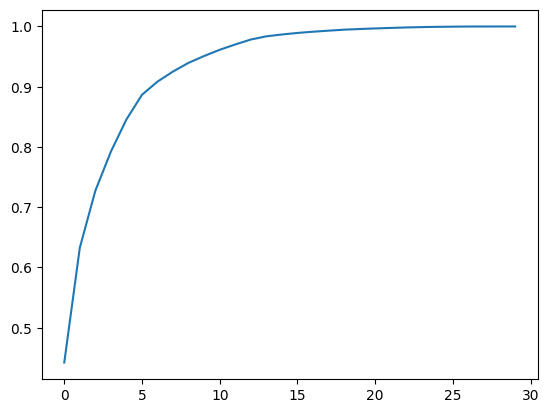

In [52]:
import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))

- Above graph say that:
  - At **X-Axis -> Number of Componets**
  - At **Y-Axis -> Say of Verience**
  - So from that we can **Before 15 componets** All more than 95% variance is explained.
  - Like that way I can pick optimal number of componets in PCA.

In [55]:
pca = PCA(n_components=15)
X_train_optimal = pca.fit_transform(X_train)
X_test_optimal = pca.transform(X_test)

- - ML model, Neighbors KNeighbors

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [57]:
knn.fit(X_train_optimal, y_train)

KNeighborsClassifier()

In [59]:
y_pred = knn.predict(X_test_optimal)

- For classification tasks like this, metrics like accuracy, precision, recall, F1-score, and the confusion matrix are more appropriate and informative.

In [62]:
from sklearn.metrics import accuracy_score
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9736842105263158
